In [1]:
# ── Cell 1: Setup ─────────────────────────────────────────────────────────────
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from src.models.baseline import RandomForestModel, XGBoostModel
from src.utils.feature_importance import (
    plot_builtin_importance,
    plot_permutation_importance,
    plot_correlation_heatmap,
    summarize_importance,
)

plt.rcParams["figure.dpi"] = 120
print("✅ Ready")


✅ Ready


In [2]:
# ── Cell 2: Build feature matrix + train both models ──────────────────────────
# (same synthetic matrix used in notebook 02 and 03)
np.random.seed(42)
n_total, n_pos = 500, 60

def make_rows(n, planet, seed_start=0):
    rows = []
    for i in range(n):
        np.random.seed(seed_start + i)
        p = np.random.uniform(5, 300)
        rows.append({
            "flux_mean":                1.0 + np.random.normal(0, 0.001),
            "flux_std":                 np.random.uniform(0.003, 0.012) if planet else np.random.uniform(0.001, 0.003),
            "flux_median":              1.0 + np.random.normal(0, 0.001),
            "flux_min":                 1.0 - (np.random.uniform(0.008, 0.02) if planet else np.random.uniform(0.001, 0.005)),
            "flux_max":                 1.0 + np.random.uniform(0.001, 0.004),
            "flux_range":               np.random.uniform(0.01, 0.025) if planet else np.random.uniform(0.001, 0.008),
            "flux_mad":                 np.random.uniform(0.0005, 0.002),
            "flux_skew":                np.random.uniform(-1.2, -0.3) if planet else np.random.uniform(-0.3, 0.3),
            "flux_kurtosis":            np.random.uniform(1.5, 5.0) if planet else np.random.uniform(-0.5, 1.5),
            "frac_below_3sigma":        np.random.uniform(0.01, 0.05) if planet else np.random.uniform(0, 0.01),
            "n_dips_detected":          np.random.uniform(5, 15) if planet else np.random.uniform(0, 3),
            "dip_mean_depth":           np.random.uniform(0.005, 0.02) if planet else np.random.uniform(0, 0.002),
            "dip_depth_std":            np.random.uniform(0, 0.003),
            "dip_max_depth":            np.random.uniform(0.01, 0.025) if planet else np.random.uniform(0, 0.003),
            "dip_depth_consistency":    np.random.uniform(0, 0.3) if planet else np.random.uniform(0.3, 1.5),
            "folded_transit_depth":     np.random.uniform(0.005, 0.02) if planet else np.nan,
            "folded_transit_depth_ppm": np.random.uniform(5000, 20000) if planet else np.nan,
            "folded_transit_width_frac":np.random.uniform(0.01, 0.05) if planet else np.nan,
            "folded_symmetry":          np.random.uniform(0, 0.002) if planet else np.nan,
            "period_days":              p if planet else np.nan,
            "log_period":               np.log10(p) if planet else np.nan,
        })
    return rows

rows = make_rows(n_total-n_pos, False, 0) + make_rows(n_pos, True, 1000)
X_all = pd.DataFrame(rows)
y_all = np.array([0]*(n_total-n_pos) + [1]*n_pos)

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

# Train both models
rf = RandomForestModel(n_estimators=300, max_depth=15)
rf.fit(X_train, y_train)

xgb = XGBoostModel(n_estimators=200, max_depth=6, learning_rate=0.05,
                   scale_pos_weight=8.3)
xgb.fit(X_train, y_train)

print(f"RF val  F1: {rf.evaluate(X_val, y_val)['f1']:.4f}")
print(f"XGB val F1: {xgb.evaluate(X_val, y_val)['f1']:.4f}")

              precision    recall  f1-score   support

   No planet       1.00      1.00      1.00        88
      Planet       1.00      1.00      1.00        12

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

RF val  F1: 1.0000
              precision    recall  f1-score   support

   No planet       1.00      1.00      1.00        88
      Planet       1.00      1.00      1.00        12

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

XGB val F1: 1.0000


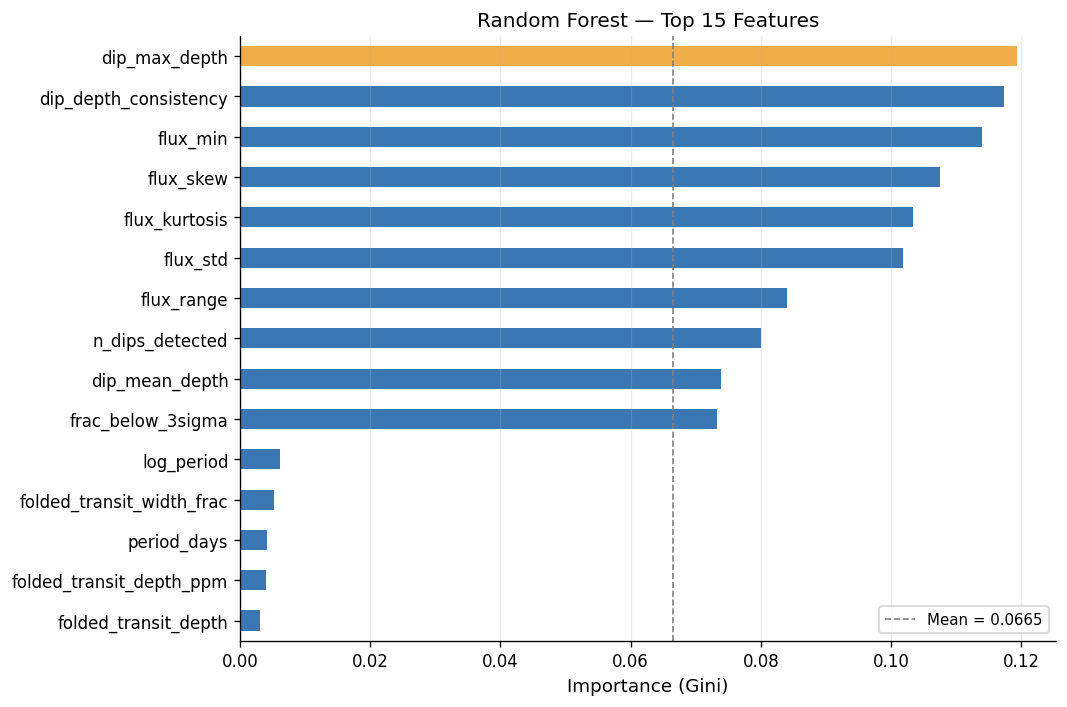


💡 Gini importance tells us what the model used, not what actually matters.
   Features used a lot in splits get high importance — but this can be misleading
   if a feature is noisy and splits on it many times without real signal.


In [3]:
# ── Cell 3: Built-in importance — Random Forest ────────────────────────────────
fig = plot_builtin_importance(rf, top_n=15, title="Random Forest")
plt.show()

print("\n💡 Gini importance tells us what the model used, not what actually matters.")
print("   Features used a lot in splits get high importance — but this can be misleading")
print("   if a feature is noisy and splits on it many times without real signal.")

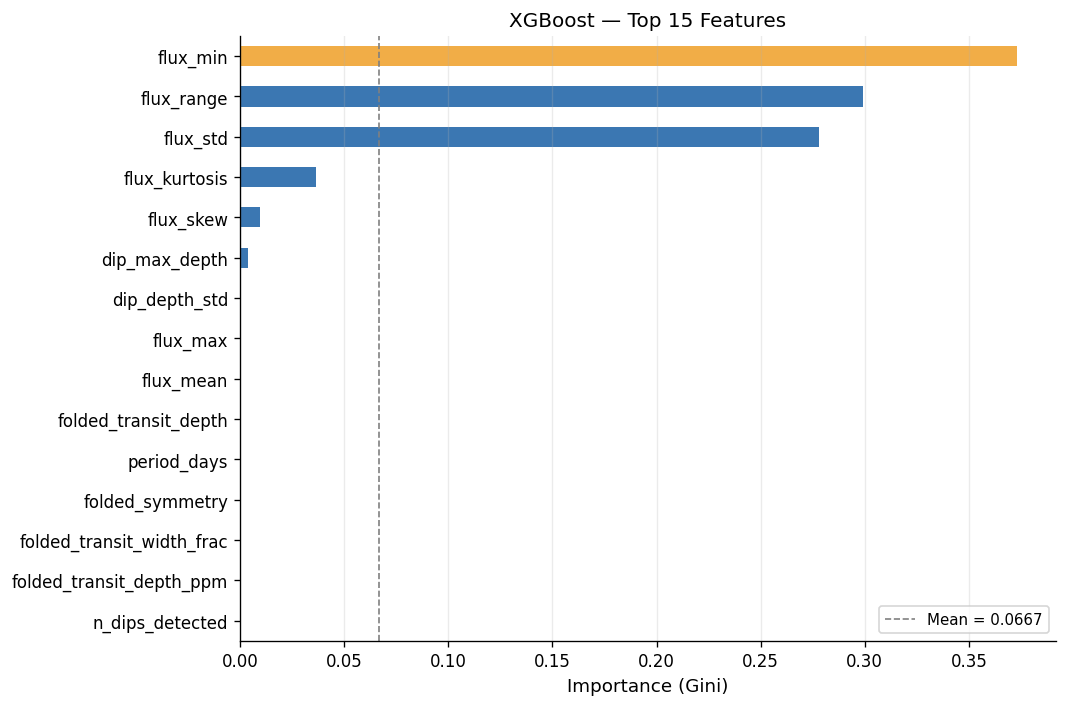


💡 Compare RF vs XGBoost rankings — features consistently important
   across both models are the strongest candidates for the CNN feature input.


In [4]:
# ── Cell 4: Built-in importance — XGBoost ─────────────────────────────────────
fig = plot_builtin_importance(xgb, top_n=15, title="XGBoost")
plt.show()

print("\n💡 Compare RF vs XGBoost rankings — features consistently important")
print("   across both models are the strongest candidates for the CNN feature input.")

Running permutation importance — takes ~30 seconds...
(Shuffles each feature 10x and measures F1 drop on validation set)



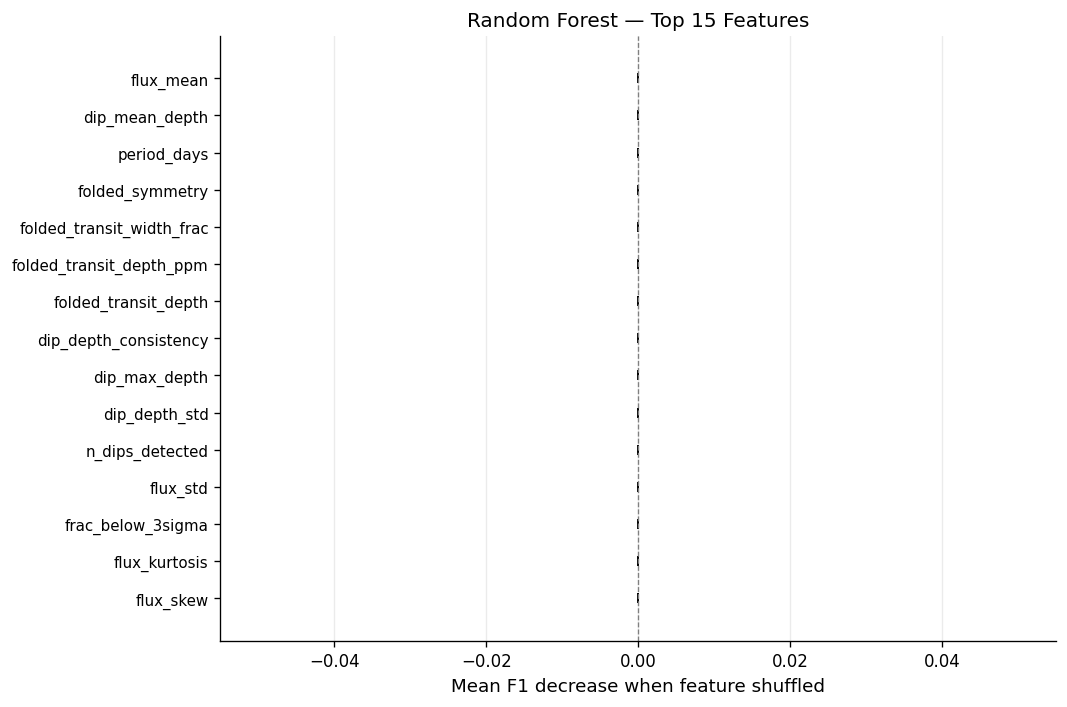


💡 Negative permutation importance = shuffling this feature IMPROVES the model
   = the feature is adding noise, not signal. Remove it in Week 3.


In [5]:

# ── Cell 5: Permutation importance (more reliable) ────────────────────────────
print("Running permutation importance — takes ~30 seconds...")
print("(Shuffles each feature 10x and measures F1 drop on validation set)\n")

fig = plot_permutation_importance(
    rf, X_val, y_val,
    top_n=15, n_repeats=10, title="Random Forest"
)
plt.show()

print("\n💡 Negative permutation importance = shuffling this feature IMPROVES the model")
print("   = the feature is adding noise, not signal. Remove it in Week 3.")


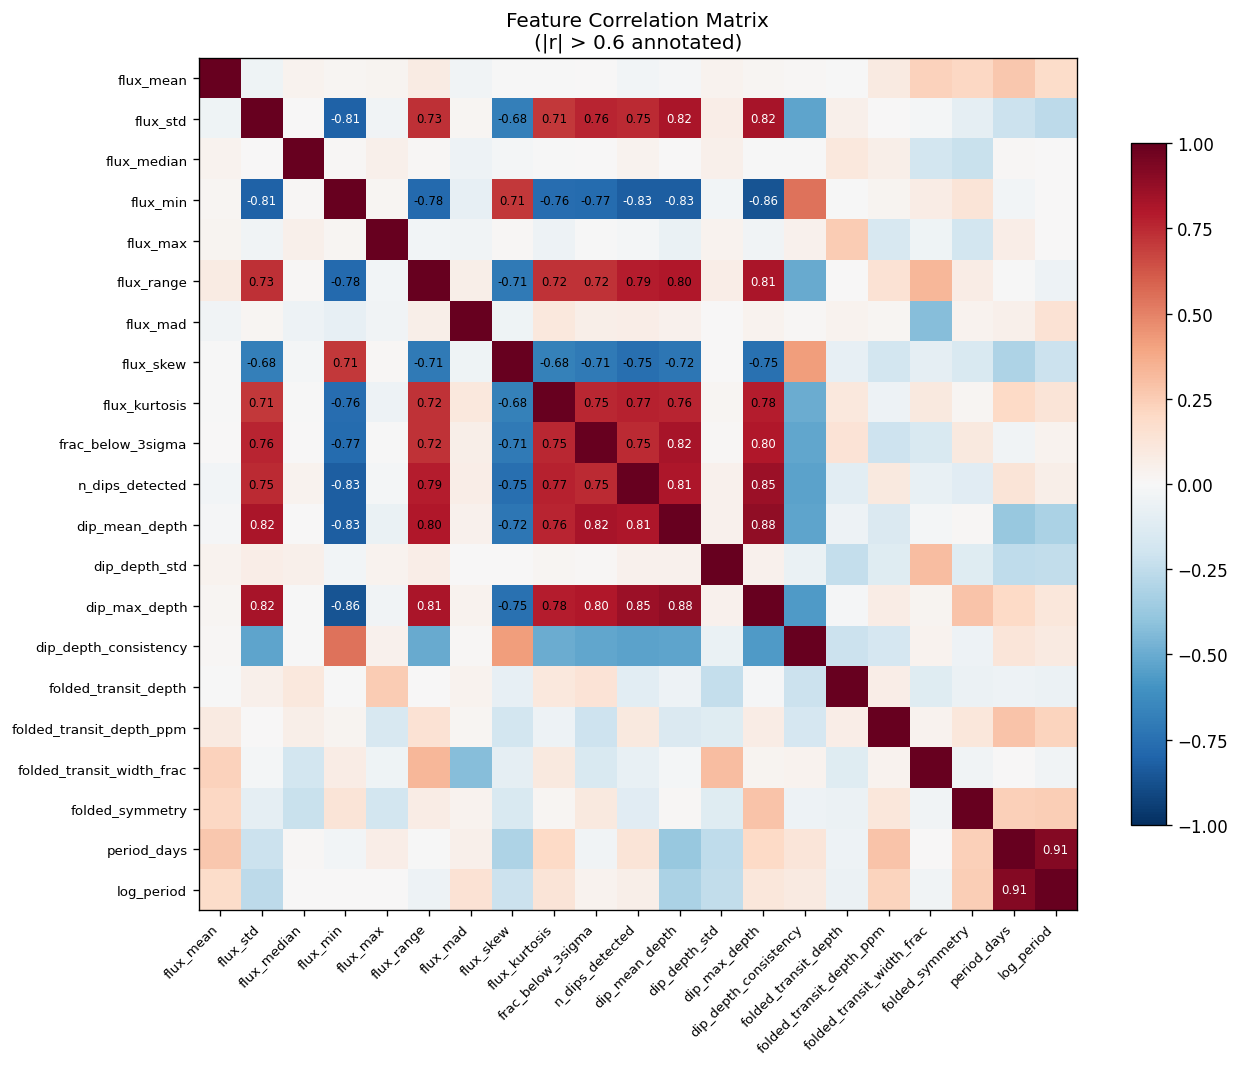


Highly correlated pairs (|r| > 0.85) — candidates for removal:
  log_period                          ↔ period_days                          r=0.914
  dip_max_depth                       ↔ dip_mean_depth                       r=0.884
  dip_max_depth                       ↔ flux_min                             r=0.863
  dip_max_depth                       ↔ n_dips_detected                      r=0.855


In [6]:
# ── Cell 6: Correlation heatmap ───────────────────────────────────────────────
fig = plot_correlation_heatmap(X_all)
plt.show()

# Find highly correlated pairs
X_numeric = X_all.select_dtypes(include=[np.number]).dropna(axis=1, how="all")
corr = X_numeric.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [(col, row, corr.loc[row, col])
             for col in upper.columns
             for row in upper.index
             if upper.loc[row, col] > 0.85]

print(f"\nHighly correlated pairs (|r| > 0.85) — candidates for removal:")
if high_corr:
    for c1, c2, r in sorted(high_corr, key=lambda x: -x[2]):
        print(f"  {c1:35s} ↔ {c2:35s}  r={r:.3f}")
else:
    print("  None found — no obviously redundant features")


In [7]:
# ── Cell 7: Combined importance summary ───────────────────────────────────────
summary = summarize_importance(rf, xgb, X_val, y_val, top_n=10)

print("\n" + "="*60)
print("KEY FINDINGS — Feature Importance Analysis")
print("="*60)

top3 = summary.index[:3].tolist()
print(f"\n✅ Top 3 features consistently important across both models:")
for i, feat in enumerate(top3, 1):
    print(f"   {i}. {feat}")

print(f"\n📋 Action items for Week 3 CNN:")
print(f"   - Phase-folded features (folded_*) are strong → validate with real data")
print(f"   - CNN will learn these patterns directly from raw folded curves")
print(f"   - Consider dropping lowest permutation importance features")


Top 10 features by average rank across RF and XGBoost:
                       rf_rank  xgb_rank  avg_rank
flux_min                     3         1       2.0
dip_max_depth                1         6       3.5
flux_skew                    4         5       4.5
flux_kurtosis                5         4       4.5
flux_std                     6         3       4.5
flux_range                   7         2       4.5
dip_depth_consistency        2        15       8.5
n_dips_detected              8        15      11.5
dip_mean_depth               9        15      12.0
frac_below_3sigma           10        15      12.5

Features ranked #1 by both models are the strongest signal.

KEY FINDINGS — Feature Importance Analysis

✅ Top 3 features consistently important across both models:
   1. flux_min
   2. dip_max_depth
   3. flux_skew

📋 Action items for Week 3 CNN:
   - Phase-folded features (folded_*) are strong → validate with real data
   - CNN will learn these patterns directly from raw folded